In [36]:
import utils
import methods
from methods import model, evaluate_metrics, quantify_tradeoff
from utils import DataGenerator, Reservoir

import pyro
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
Time_steps = 2000
tau = 20
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()
X.shape, Y.shape

((2000, 1), (2000, 1))

In [3]:
X_train = X[:1000,:]
X_test = X[1000:,:]
X_train.shape, X_test.shape

((1000, 1), (1000, 1))

In [4]:
input_dim = X_train.shape[1]
reservoir_dim = 500
spectral_radius = 0.9
seed = 42

res = Reservoir(input_dim, reservoir_dim, spectral_radius, seed)

S_train = res.get_states(X_train)
S_test = res.get_states(X_test)

print(f"Input shape: {X_train.shape}")
print(f"Reservoir States shape: {S_train.shape}")

Input shape: (1000, 1)
Reservoir States shape: (1000, 500)


In [5]:
n_components = 16

S_train_PCA, S_test_PCA = utils.get_reduced_states(Reservoir(input_dim, reservoir_dim, spectral_radius, seed), X_train, X_test, n_components)

Original dim: (1000, 500)
Reduced dim:  (1000, 16)


In [6]:
Y_train = Y[:1000]

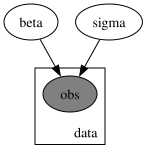

In [7]:
pyro.render_model(model, model_args=(S_train, Y_train))

$
\text{TotalCost}_{\text{HMC}} \approx (\text{Num Samples})\times(\text{Leapfrog Steps per Sample})\times(\text{Gradient Cost}),
$
with:
+ $\text{Gradient Cost} \sim \texttt{TimeSteps}\times\texttt{input\_dim}$
+ $\text{Leapfrog Steps} \sim \operatorname{O}(\texttt{input\_dim})$

Thus run $\text{HMC}$ sampler to sample $Y$. Two parameters will be shown. The $\texttt{step size}\,\,\Delta t$ is the integration step by used by the Leapfrog integrator. Pyro automatically identifies the value that allow to safely explore the whole distribution. The $\texttt{acc. prob}$ which is the frequency with which the sampler accepts the new proposed state at the end of a trajectory.

In [8]:
num_samples = 200

nut_kernel = pyro.infer.NUTS(model)
mcmc = pyro.infer.MCMC(nut_kernel, num_samples=num_samples, warmup_steps=200)
mcmc.run(S_train_PCA, Y_train)

Sample: 100%|██████████| 400/400 [01:37,  4.10it/s, step size=5.47e-03, acc. prob=0.927]


In [9]:
param_samples = mcmc.get_samples()

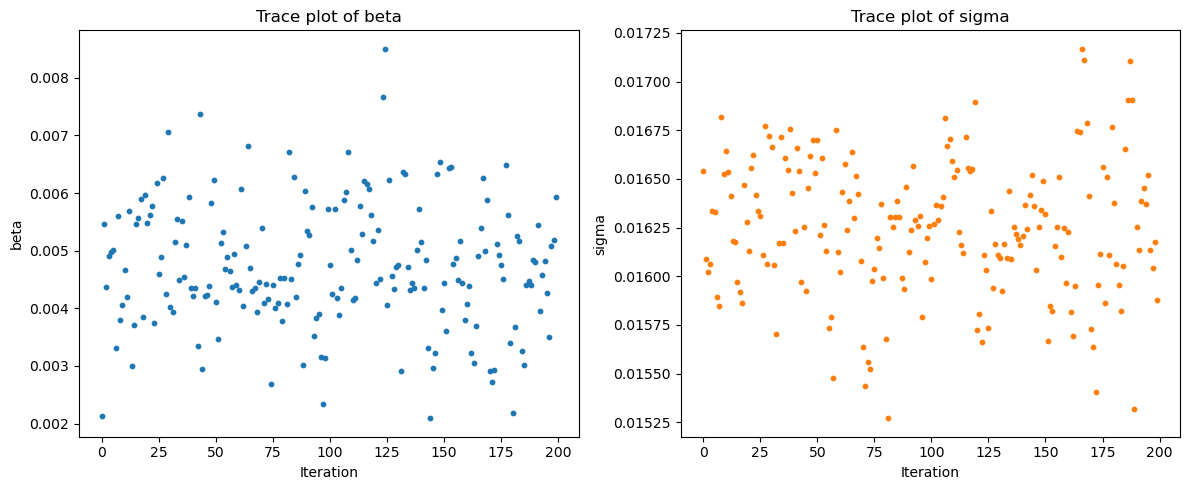

In [10]:
beta_samples = param_samples['beta'].squeeze().mean(1)
sigma_samples = param_samples['sigma'].squeeze()

iterations = np.arange(len(beta_samples))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(iterations, beta_samples, s=10, alpha=1)
plt.xlabel("Iteration")
plt.ylabel("beta")
plt.title("Trace plot of beta")

plt.subplot(1,2,2)
plt.scatter(iterations, sigma_samples, s=10, alpha=1, color="C1")
plt.xlabel("Iteration")
plt.ylabel("sigma")
plt.title("Trace plot of sigma")

plt.tight_layout()
plt.show()

In [11]:
# # Noice plotting
# import arviz as az
# az.plot_trace(mcmc)

The trajectory outlines a Posterior Predictive Distribution that allows to estimate the uncertainty in the MAP estimates in $\beta$ and $\sigma$, which is the ultimate goal of our Bayesian Reservoir Computer.

In [12]:
Y_test = Y[1000:]
predictive = pyro.infer.Predictive(model, posterior_samples=param_samples, num_samples=None, parallel=True)
y_pred_samples = predictive(S_test_PCA, None)["obs"]

print("Shape of predictions:", y_pred_samples.shape, type(y_pred_samples))

Shape of predictions: torch.Size([200, 1000]) <class 'torch.Tensor'>


In [13]:
median_prediction = y_pred_samples.median(0)[0]
mean_prediction = y_pred_samples.mean(0)
std_prediction = y_pred_samples.std(0)

# 95% Confidence Interval
lower_bound = mean_prediction - 2 * std_prediction
upper_bound = mean_prediction + 2 * std_prediction

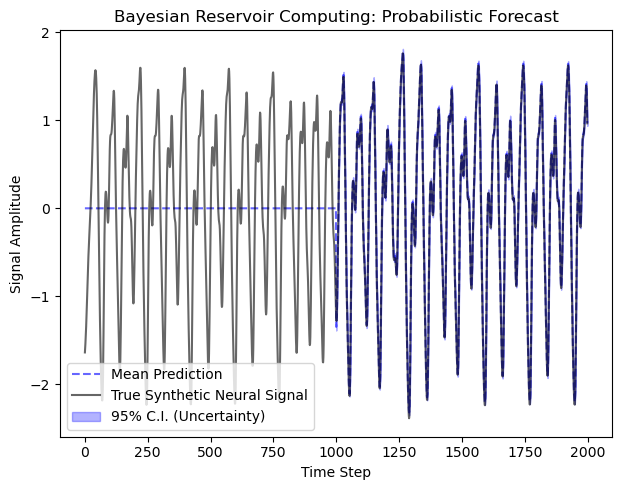

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(np.hstack((np.zeros(len(Y_train)), mean_prediction.detach().numpy())), "b--", alpha=0.6, label="Mean Prediction")
plt.plot(Y, "k-", alpha=0.6, label="True Synthetic Neural Signal")
plt.fill_between(
    range(len(Y_train), len(mean_prediction)+len(Y_train)),
    lower_bound,
    upper_bound,
    color="blue",
    alpha=0.3,
    label="95% C.I. (Uncertainty)"
)
plt.xlabel("Time Step")
plt.ylabel("Signal Amplitude")
plt.title("Bayesian Reservoir Computing: Probabilistic Forecast")
plt.tight_layout()
plt.legend()
plt.show()

Notice:
+ The predicted signal shows caothic dynamics (as it should), in the sense that is oscillates, aperiodically, without repeating the same pattern.
+ In a chaotic system, uncertainty is state-dependent, meaning the dynamics are predictable (narrow C.I.), for stable regions, and vice-versa for unstable regions.
+ The C.I. fully captures the true signal. The C.I. gets narrower when the signal changes direction less rapidly (iterations $\in(1100,1200)$).
We further test for a tighter noise interval. 

To notice whether the true signal does not fall inside the uncertainty bands, we aim to formally evaluate the model using metrics that penalize both for being wrong (inexact signal amplitude / too narrow condifence interval) and "unecessarily unsure" (too wide confidence interval). We use a twofold approach:
+ Calibration Error (cal): ( from the paper "how much the empirical CDF veers from the theoretical one"). Namely:
    $$
    \text{cal}=\sum_{i=1}^K w_i (\tau_i - \tilde{\tau}_i)^2
    $$
+ Empirical Coverage (ecov):  Measures the width and the coverage of the $95\%\, \text{C.I.}$. A smaller width reflects a less uncertain forecast, while the coverage should be close to $0.95$. Namely
    $$
    \text{ecov} = \frac{1}T\sum_{i=t}^T\mathbb{1}_{[\text{CI}_{\text{low}}\,\le\, y_t \,\le\, \text{CI}_{\text{high}}]}
    $$
+ mCRPS (mean Continuous Ranked Probability Score): measures the average distance between the predicted CDF and the Heaviside function $\theta$. CRPS can be interpreted as a combined
measure of both the accuracy (MSE) and calibration (cal).
    $$
    \mathrm{CRPS}(F, x)
    =
    \int \big( F(y) - \theta(y - x) \big)^2 \, dy.\\
    \mathrm{mCRPS}(F) = \mathbb{E}_y \big[ \mathrm{CRPS}(F, y) \big].
    $$

## Grid Search

We perform a gridsearch over a set of paramters w.r.t. the mCRPS.

In [15]:
import torch
import pyro
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

In [16]:
class BayesianReservoirMCMC(BaseEstimator, RegressorMixin):
    def __init__(self, beta_params=(0, 1.0), scale=(0, 1.0), n_components=16, 
                 num_samples=200, warmup_steps=200, input_dim=1, reservoir_dim=100, 
                 spectral_radius=0.9, seed=42):
        # Scikit-learn requires all hyperparameters to be explicitly bound to self
        self.beta_params = beta_params
        self.scale = scale
        self.n_components = n_components
        self.num_samples = num_samples
        self.warmup_steps = warmup_steps
        
        self.input_dim = input_dim
        self.reservoir_dim = reservoir_dim
        self.spectral_radius = spectral_radius
        self.seed = seed

    def fit(self, X, y):
        # 1. State Projection
        self.reservoir_ = Reservoir(self.input_dim, self.reservoir_dim, self.spectral_radius, self.seed)
        states = self.reservoir_.get_states(X)

        # 2. Dimensionality Reduction
        self.pca_ = PCA(n_components=self.n_components)
        S_train_PCA = self.pca_.fit_transform(states)

        # 3. MCMC Inference
        S_tensor = torch.tensor(S_train_PCA, dtype=torch.float64)
        y_tensor = torch.tensor(y, dtype=torch.float64).squeeze()

        nut_kernel = pyro.infer.NUTS(model)
        self.mcmc_ = pyro.infer.MCMC(nut_kernel, num_samples=self.num_samples, warmup_steps=self.warmup_steps)
        self.mcmc_.run(S_tensor, y_tensor, self.beta_params, self.scale)
        
        self.posterior_samples_ = self.mcmc_.get_samples()
        return self

    def predict(self, X):
        # Generate full predictive distribution
        states = self.reservoir_.get_states(X)
        S_test_PCA = self.pca_.transform(states)
        S_tensor = torch.tensor(S_test_PCA, dtype=torch.float64)

        predictive = pyro.infer.Predictive(model, posterior_samples=self.posterior_samples_, num_samples=None, parallel=True)
        self.y_pred_samples_ = predictive(S_tensor, None)["obs"]
        
        # Scikit-learn requires point estimates for standard array operations
        return self.y_pred_samples_.mean(dim=0).detach().cpu().numpy()

    def score(self, X, y):
        # Trigger predictive sampling
        self.predict(X) 
        
        y_tensor = torch.tensor(y, dtype=torch.float64).squeeze()
        
        # Extract mCRPS using the internal 2D tensor, bypassing sklearn's 1D point requirement
        _, _, mcrps, _ = evaluate_metrics(self.y_pred_samples_, y_tensor)
        
        # GridSearchCV strictly maximizes scores. Return negative CRPS to optimize for minimum error.
        return -mcrps.mean().item()

In [26]:
param_grid = {
    "beta_params": [(0, 1e-2), (0, 1e-1), (0, 1e0), (0, 1e1), (0, 1e2)],
    "scale": [1e-2, 1e-1, 1e0, 1e1, 1e2],
    "n_components": [4, 16, 64, 128],
    "spectral_radius": [0.3, 0.5, 0.7, 0.9]
}

param_grid = {
    "beta_params": [(0, 1e-2), (0, 1e0), (0, 1e1)],
    "scale": [1e-2, 1e0, 1e1],
    "n_components": [4, 16, 128],
    "spectral_radius": [0.3, 0.6, 0.9]
}

mcmc_estimator = BayesianReservoirMCMC(
    input_dim=1, 
    reservoir_dim=500, 
    spectral_radius=0.9, 
    seed=42, 
    num_samples=200, 
    warmup_steps=200
)

gs = GridSearchCV(
    estimator=mcmc_estimator, 
    param_grid=param_grid, 
    cv=3,
    n_jobs=1,  
    verbose=1
)

In [27]:
gs.fit(X_train, Y_train)
best_params = gs.best_params_
best_mcrps = -gs.best_score_

Fitting 3 folds for each of 81 candidates, totalling 243 fits


Sample: 100%|██████████| 400/400 [04:09,  1.60it/s, step size=5.11e-03, acc. prob=0.945]


Optimal Hyperparameters: {'beta_params': (0, 1.0), 'n_components': 128, 'scale': 1.0, 'spectral_radius': 0.3}
Minimum mCRPS Score: 0.012398266661286357


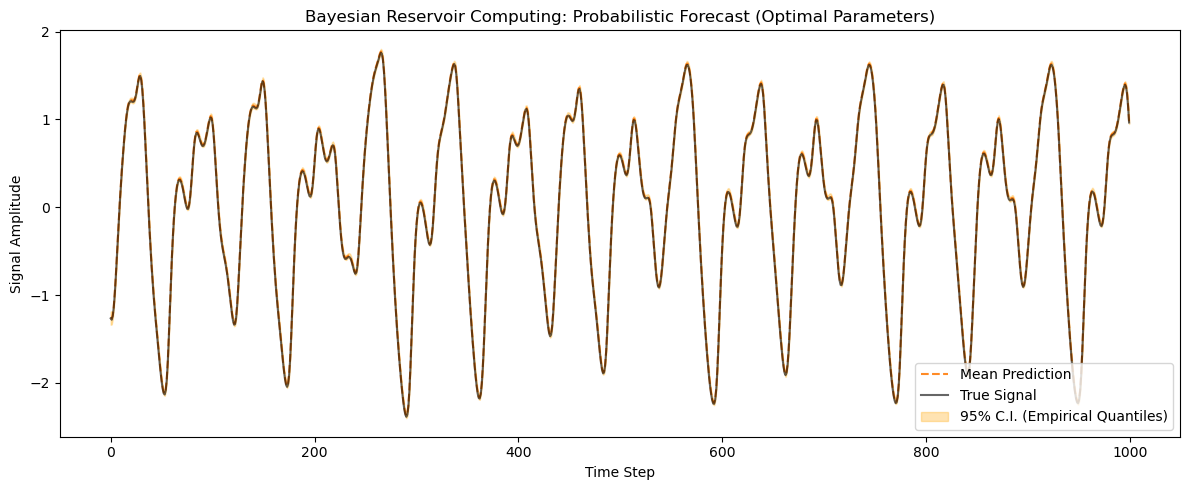

In [28]:
# 1. Extract Best Hyperparameters
print("Optimal Hyperparameters:", gs.best_params_)
print("Minimum mCRPS Score:", -gs.best_score_)

# 2. Isolate the Refitted Optimal Model
best_model = gs.best_estimator_

# 3. Trigger Predictive Sampling on Test Set
_ = best_model.predict(X_test)

# 4. Extract Predictive Distribution Tensor
y_pred_samples_best = best_model.y_pred_samples_

# 5. Compute Statistical Moments and Empirical Quantiles
mean_prediction_best = y_pred_samples_best.mean(dim=0).detach().cpu().numpy().squeeze()
lower_bound_best = torch.quantile(y_pred_samples_best, 0.025, dim=0).detach().cpu().numpy().squeeze()
upper_bound_best = torch.quantile(y_pred_samples_best, 0.975, dim=0).detach().cpu().numpy().squeeze()

Y_test_flat = Y_test.squeeze()

# 6. Execute Visualization
plt.figure(figsize=(12, 5))

plt.plot(mean_prediction_best, "C1--", alpha=0.9, label="Mean Prediction")
plt.plot(Y_test_flat, "k-", alpha=0.6, label="True Signal")
plt.fill_between(
    range(len(mean_prediction_best)),
    lower_bound_best,
    upper_bound_best,
    color="orange",
    alpha=0.3,
    label="95% C.I. (Empirical Quantiles)"
)

plt.xlabel("Time Step")
plt.ylabel("Signal Amplitude")
plt.title("Bayesian Reservoir Computing: Probabilistic Forecast (Optimal Parameters)")
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
cov_best, cal_best, mcrps_best, width_best = evaluate_metrics(y_pred_samples_best, Y_test)

best_beta = gs.best_params_['beta_params']
best_scale = gs.best_params_['scale']
best_components = gs.best_params_['n_components']
best_radius = gs.best_params_['specatral_radius']

print(f"Optimal Params:\tbeta~Normal{best_beta}\tscale~Uniform{best_scale}\tn_components: {best_components}\tspectral radius: {best_radius}")
print(f"Empirical Coverage (optimized): {cov_best[0]:.2%} (Target: 95%)")
print(f"Calibration Error (optimized): {cal_best[0]:.2%} (Target: 0.0000)")
print(f"mCRPS (optimized): {mcrps_best[0]:.4f} (Lower is better)")
print(f"Width (optimized): {width_best[0]:.4f} (Lower is better)")

Optimal Params:	beta~Normal(0, 1.0)	scale~Uniform1.0	n_components: 128
Empirical Coverage (optimized): 100.00% (Target: 95%)
Calibration Error (optimized): 25.12% (Target: 0.0000)
mCRPS (optimized): 0.0087 (Lower is better)
Width (optimized): 0.0566 (Lower is better)


In [ ]:
# first results (sigma ~ HalfNormal[10.])
cov, cal, mcrps, width = evaluate_metrics(y_pred_samples, Y_test)
print(f"Inference Params:\tbeta~Normal(0,10.)\tscale~HalfNormal(10.)\tn_components: 16\tspectral radius: 0.9")
print(f"Empirical Coverage (constrained): {cov[0]:.2%} (Target: 95%)")
print(f"Calibration Error (constrained): {cal[0]:.2%} (Target: 0%)")
print(f"mCRPS (constrained): {mcrps[0]:.4f} (Lower is better)")
print(f"Width (constrained): {width[0]:.4f} (Lower is better)")

Inference Params:	beta~Normal(0,10.)	scale~HalfNormal(10.)
Empirical Coverage (constrained): 97.40% (Target: 95%)
Calibration Error (constrained): 21.96% (Target: 0%)
mCRPS (constrained): 0.0098 (Lower is better)
Width (constrained): 0.0625 (Lower is better)


In summary, 

The Reservoir acts as a fixed, non-linear dynamical filter that projects the low-dimensional input to a high-dimensional **state space**, determined by the projection $s(t)=f(W_{\text{in}} x(t) + W s(t-1)).$ This allows the system to develop a "short-term memory" required to predict the chaotic Mackey-Glass system (where the future depends on $t-\tau$).

The Bayesian Regression layer then takes these states and maps them to the output. Unlike standard regression, it treats the weights $\beta$ and noise $\sigma$ as **stochastic** variables, defined by the posterior probability distribution $P(\beta, \sigma|\mathcal{D})$. This allows us to quantify:
+ The **epistemic** uncertainty (uncertainty about the dynamics). Quantified the variance of the posterior predictive mean $\operatorname{Var}(s(t)^T\beta)$.
+ The **aleatoric** uncertainty (measurement noise). Quantified by the observation noise variance $\sigma^2$, representing the stochasticity of the system measurements and providing a "cloud of probability" (the C.I. band) that tracks the chaotic attractor.

A constrained model (prior for the observation noise variance $\sigma\sim\mathcal{U}[0, 0.05]$) leads to a sharper C.I. band, able to reproduce the dynamics of the true signal. However, scoring a low empirical coverage. The unconstrained model performs better over all metrics. 

Now, we want to quantify the trade-off between calibration (empirical coverage approaching 0.95) and sharpness (minimization of CRPS), across the two probabilistic regimes.

## Metrics

In [34]:
from utils import ComplexRadar, plot_parallel_coordinates_ci
import numpy as np
import matplotlib.pyplot as plt
from methods import evaluate_metrics, quantify_tradeoff

In [ ]:
# 1. Extract Top 3 Configurations
cv_results = pd.DataFrame(gs.cv_results_)
cv_results.to_csv("results/synth_grid_search_results.csv", index=False)
top_3_idx = cv_results['rank_test_score'].nsmallest(3).index
top_3_params = cv_results.loc[top_3_idx, 'params'].tolist()

In [31]:
n_iterations = 5
metrics_data = {"Cal": {}, "Cov": {}, "mCRPS": {}, "Width": {}}

In [38]:
# 2. Iterative Evaluation
for rank, params in enumerate(top_3_params, 1):
    model_name = f"Rank {rank}"
    for m in metrics_data:
        metrics_data[m][model_name] = []
        
    for i in range(n_iterations):
        print(f"Evaluating {model_name} - Iteration {i+1}/{n_iterations}")
        
        # Inject iteration index into seed for stochastic isolation
        iteration_seed = 42 + i 
        
        model_hs = BayesianReservoirMCMC(
            beta_params=params["beta_params"],
            scale=params["scale"],
            n_components=params["n_components"],
            input_dim=1,
            reservoir_dim=500,
            spectral_radius=params["spectral_radius"],
            seed=iteration_seed,
            num_samples=200,
            warmup_steps=200
        )

        model_hs.fit(X_train, Y_train)
        model_hs.predict(X_test)
        
        y_tensor = torch.tensor(Y_test, dtype=torch.float64).squeeze()
        cov, cal, mcrps, width = evaluate_metrics(model_hs.y_pred_samples_, y_tensor)
        
        # Collapse spatial dimension for scalar dictionary storage
        metrics_data["Cov"][model_name].append(cov.mean().item())
        metrics_data["Cal"][model_name].append(cal.mean().item())
        metrics_data["mCRPS"][model_name].append(mcrps.mean().item())
        metrics_data["Width"][model_name].append(width.mean().item())

Evaluating Rank 1 - Iteration 1/5


Sample: 100%|██████████| 400/400 [04:39,  1.43it/s, step size=4.87e-03, acc. prob=0.952]


Evaluating Rank 1 - Iteration 2/5


Sample: 100%|██████████| 400/400 [04:30,  1.48it/s, step size=5.10e-03, acc. prob=0.944]


Evaluating Rank 1 - Iteration 3/5


...

Sample: 100%|██████████| 400/400 [02:39,  2.51it/s, step size=5.19e-03, acc. prob=0.930]


Evaluating Rank 3 - Iteration 4/5


Sample: 100%|██████████| 400/400 [02:48,  2.37it/s, step size=4.45e-03, acc. prob=0.954]


Evaluating Rank 3 - Iteration 5/5


Sample: 100%|██████████| 400/400 [02:20,  2.85it/s, step size=5.36e-03, acc. prob=0.926]


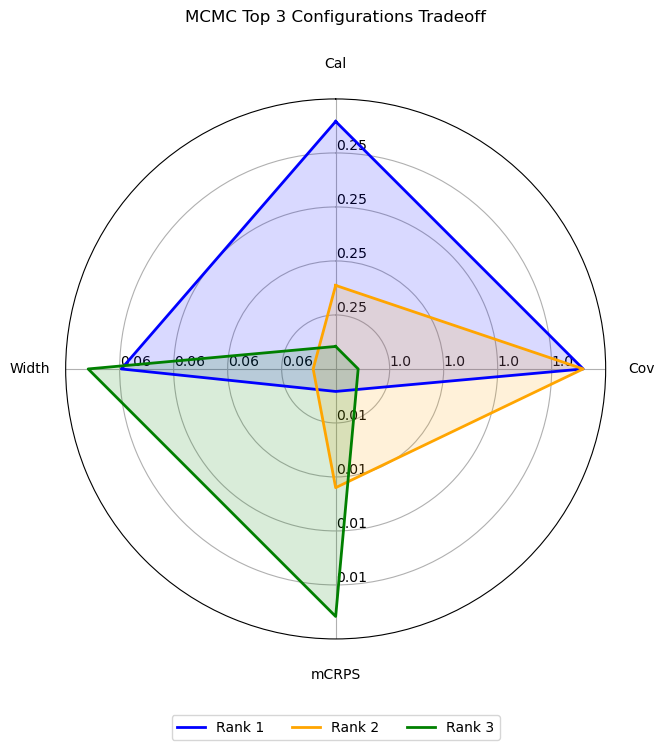

In [39]:
# 3. Radar Chart Projection
metrics = list(metrics_data.keys())
models = list(metrics_data[metrics[0]].keys())

data_matrix = {model: [np.mean(metrics_data[metric][model]) for metric in metrics] for model in models}

ranges = []
for i, metric in enumerate(metrics):
    vals = [data_matrix[m][i] for m in models]
    vmin, vmax = min(vals), max(vals)
    if vmin == vmax:
        ranges.append((vmin - 0.1, vmax + 0.1))
    else:
        padding = (vmax - vmin) * 0.1
        ranges.append((vmin - padding, vmax + padding))

fig1 = plt.figure(figsize=(6, 6))
radar = ComplexRadar(fig1, metrics, ranges)

colors = ['blue', 'orange', 'green']

for i, model in enumerate(models):
    radar.plot(data_matrix[model], label=model, color=colors[i], linewidth=2)
    radar.fill(data_matrix[model], facecolor=colors[i], alpha=0.15)

radar.ax.set_title("MCMC Top 3 Configurations Tradeoff", pad=25)
radar.use_legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(models))
plt.show()

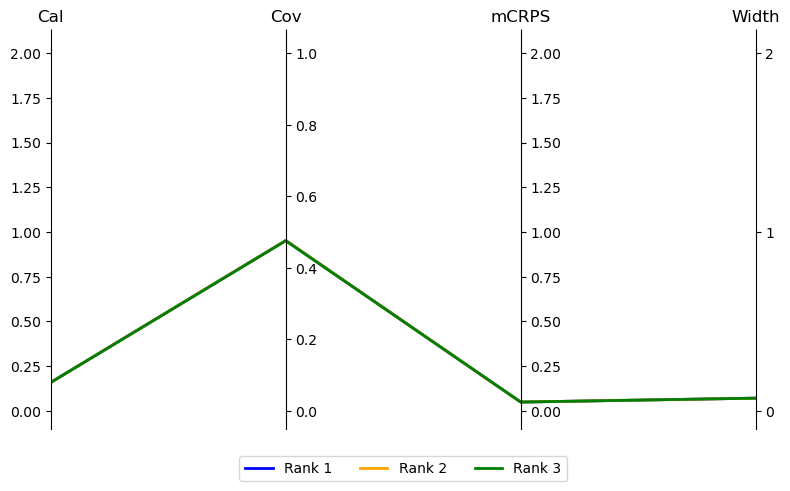

In [44]:
# 4. Parallel Coordinates Projection
bounds = {
    "Cal": [0, 2],
    "Cov": [0, 1],
    "mCRPS": [0, 2],
    "Width": [0, 2]
}

plot_parallel_coordinates_ci(metrics_data, bounds=bounds, colors=colors)

In [41]:
def quantify_tradeoff(metrics_data, baseline_config="Rank 1"):
    metrics = list(metrics_data.keys())
    models = list(metrics_data[metrics[0]].keys())
    
    results = pd.DataFrame({
        "Configuration": models,
        "Cov": [np.mean(metrics_data["Cov"][m]) for m in models],
        "Cal": [np.mean(metrics_data["Cal"][m]) for m in models],
        "mCRPS": [np.mean(metrics_data["mCRPS"][m]) for m in models],
        "Width": [np.mean(metrics_data["Width"][m]) for m in models]
    })
    
    baseline_idx = models.index(baseline_config)
    
    results["mCRPS (Total Degradation)"] = results["mCRPS"] - results["mCRPS"].iloc[baseline_idx]
    results["Width (Sharpness Degradation)"] = results["Width"] - results["Width"].iloc[baseline_idx]

    return results

In [48]:
tradeoff_results = quantify_tradeoff(metrics_data)
tradeoff_results, top_3_params

(  Configuration     Cov       Cal     mCRPS     Width  \
 0        Rank 1  1.0000  0.250451  0.008656  0.056791   
 1        Rank 2  1.0000  0.250251  0.008684  0.056451   
 2        Rank 3  0.9984  0.250177  0.008721  0.056849   
 
    mCRPS (Total Degradation)  Width (Sharpness Degradation)  
 0                   0.000000                       0.000000  
 1                   0.000028                      -0.000340  
 2                   0.000065                       0.000059  ,
 [{'beta_params': (0, 1.0),
   'n_components': 128,
   'scale': 1.0,
   'spectral_radius': 0.3},
  {'beta_params': (0, 10.0),
   'n_components': 16,
   'scale': 1.0,
   'spectral_radius': 0.3},
  {'beta_params': (0, 10.0),
   'n_components': 16,
   'scale': 1.0,
   'spectral_radius': 0.6}])